Dropped column: LogReturn

✅ SVR Model Evaluation:
Mean Absolute Error (MAE): 0.0250
Root Mean Squared Error (RMSE): 0.0319
R² Score: -1.0341

📊 Monthly Sector-Level Aggregation:
                   Sector  YearMonth  Actual_Return  Predicted_Return  \
0  Communication Services 2024-10-01       0.002403          0.024166   
1  Communication Services 2024-11-01       0.006467          0.034477   
2  Communication Services 2024-12-01      -0.000560          0.016611   
3  Communication Services 2025-01-01       0.003199          0.009494   
4  Communication Services 2025-02-01       0.000762          0.021835   

  Actual_Direction Predicted_Direction  
0               up                  up  
1               up                  up  
2             down                  up  
3               up                  up  
4               up                  up  

📁 Final results saved to 'svr_returns_output.csv'

📊 Directional Classification Report:
              precision    recall  f1-score   s

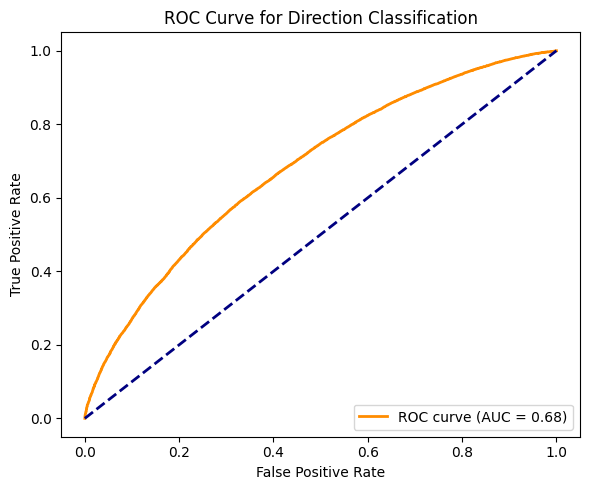

In [1]:
# %% Import Libraries
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.svm import SVR
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer  # Import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, roc_curve, auc, f1_score
)
import matplotlib.pyplot as plt

# %% Step 1: Load and Clean Data
def load_and_prepare_data(filepath, target_column='Return', drop_columns=None, date_column='Date'):
    df = pd.read_csv('indicators_daily.csv')

    if drop_columns:
        for col in drop_columns:
            if col in df.columns:
                df.drop(columns=['LogReturn'], inplace=True) # Corrected inplace to drop the actual column
                print(f"Dropped column: {col}")

    if target_column not in df.columns:
        raise KeyError(f"Column '{target_column}' not found in the dataset.")

    if date_column in df.columns:
        df[date_column] = pd.to_datetime(df[date_column], errors='coerce')
        df.dropna(subset=[date_column], inplace=True)

    df.dropna(subset=[target_column], inplace=True)
    return df

# %% Step 2: Encode Categorical Features
def encode_categoricals(df, exclude_columns=None):
    df = df.copy()
    label_encoders = {}
    for col in df.columns:
        if exclude_columns and col in exclude_columns:
            continue
        if df[col].dtype == 'object':
            le = LabelEncoder()
            # Ensure there are no NaNs in the column before fitting
            df[col] = df[col].astype(str).fillna('missing') # Handle potential NaNs before encoding
            df[col] = le.fit_transform(df[col])
            label_encoders[col] = le
    return df, label_encoders

# %% Step 3: Impute Missing Values (New Step)
def impute_missing_values(X_train, X_test, strategy='mean'):
    imputer = SimpleImputer(strategy=strategy)
    X_train_imputed = imputer.fit_transform(X_train)
    X_test_imputed = imputer.transform(X_test)
    return X_train_imputed, X_test_imputed

# %% Step 4: Scale Features
def scale_features(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

# %% Step 5: Train and Evaluate SVR Model
def train_evaluate_svr(X_train, y_train, X_test, y_test):
    svr = SVR(kernel='linear', C=1.0, epsilon=0.1)
    svr.fit(X_train, y_train)
    y_pred = svr.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("\n✅ SVR Model Evaluation:")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

    return svr, y_pred

# %% Step 6: Aggregate Monthly Returns by Sector
def aggregate_monthly_returns(df_test, y_test, y_pred):
    df_test = df_test.copy()
    df_test['Actual_Return'] = y_test
    df_test['Predicted_Return'] = y_pred
    df_test['Date'] = pd.to_datetime(df_test['Date'], errors='coerce')
    df_test['YearMonth'] = df_test['Date'].dt.to_period('M')

    monthly_agg = df_test.groupby(['Sector', 'YearMonth'])[['Actual_Return', 'Predicted_Return']].mean().reset_index()
    monthly_agg['YearMonth'] = monthly_agg['YearMonth'].dt.to_timestamp()

    monthly_agg['Actual_Direction'] = np.where(monthly_agg['Actual_Return'] > 0, 'up', 'down')
    monthly_agg['Predicted_Direction'] = np.where(monthly_agg['Predicted_Return'] > 0, 'up', 'down')

    print("\n📊 Monthly Sector-Level Aggregation:")
    print(monthly_agg.head())
    return monthly_agg

# %% Step 7: Save Final Results to CSV
def save_final_results(df_test, y_test, y_pred, output_path='svr_returns_output.csv'):
    final_df = df_test.copy()
    final_df['Actual_Return'] = y_test
    final_df['Predicted_Return'] = y_pred
    final_df['Actual_Direction'] = np.where(y_test > 0, 'up', 'down')
    final_df['Predicted_Direction'] = np.where(y_pred > 0, 'up', 'down')

    final_df = final_df[['Date', 'Sector', 'Actual_Return', 'Predicted_Return', 'Actual_Direction', 'Predicted_Direction'] +
                        [col for col in final_df.columns if col not in ['Date', 'Sector', 'Actual_Return', 'Predicted_Return', 'Actual_Direction', 'Predicted_Direction']]]

    final_df.to_csv(output_path, index=False)
    print(f"\n📁 Final results saved to '{output_path}'")

# %% Step 8: Direction Classification Metrics and ROC Curve
def evaluate_direction_classification(y_test, y_pred):
    actual_direction = np.where(y_test > 0, 1, 0)
    predicted_direction = np.where(y_pred > 0, 1, 0)

    print("\n📊 Directional Classification Report:")
    print(classification_report(actual_direction, predicted_direction, target_names=['down', 'up']))

    f1 = f1_score(actual_direction, predicted_direction, average='binary')
    print(f"F1 Score (binary): {f1:.4f}")

    print("Confusion Matrix:")
    print(confusion_matrix(actual_direction, predicted_direction))

    fpr, tpr, thresholds = roc_curve(actual_direction, y_pred)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Direction Classification')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

# %% Run Pipeline
if __name__ == "__main__":
    df = load_and_prepare_data(
        filepath='indicators_daily.csv',
        drop_columns=['LogReturn'],
        date_column='Date'
    )

    train_start = datetime(2022, 10, 1)
    train_end   = datetime(2024, 9, 30)
    test_start  = datetime(2024, 10, 1)
    test_end    = datetime(2025, 9, 30)

    df_train = df[(df['Date'] >= train_start) & (df['Date'] <= train_end)].copy()
    df_test  = df[(df['Date'] >= test_start) & (df['Date'] <= test_end)].copy()

    target = 'Return'
    feature_columns = [col for col in df.columns if col not in [target, 'Date']]

    X_train_encoded, _ = encode_categoricals(df_train[feature_columns])
    X_test_encoded, _  = encode_categoricals(df_test[feature_columns])
    y_train = df_train[target]
    y_test  = df_test[target]

    # Impute missing values after encoding and before scaling
    X_train_imputed, X_test_imputed = impute_missing_values(X_train_encoded, X_test_encoded)

    X_train_scaled, X_test_scaled = scale_features(X_train_imputed, X_test_imputed)

    model, y_pred = train_evaluate_svr(X_train_scaled, y_train, X_test_scaled, y_test)

    monthly_summary = aggregate_monthly_returns(df_test, y_test, y_pred)
    save_final_results(df_test, y_test, y_pred)
    evaluate_direction_classification(y_test, y_pred)

/var/folders/5_/c20qy50s35jdz3bv32kv3lpw0000gn/T/ipykernel_9269/3251016585.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  strat_ret = sec_daily.groupby('Date').apply(_avg_selected).rename('strategy').sort_index()


QS window: 2024-11-01 → 2025-10-01
                     strategy  benchmark
Date                                    
2024-11-01 04:00:00 -0.002209  -0.002017
2024-11-04 05:00:00 -0.000652  -0.000485
2024-11-05 05:00:00  0.013363   0.012956


                           Benchmark    Strategy
-------------------------  -----------  ----------
Start Period               2024-11-01   2024-11-01
End Period                 2025-10-01   2025-10-01
Risk-Free Rate             0.0%         0.0%
Time in Market             100.0%       100.0%

Cumulative Return          21.2%        20.55%
CAGR﹪                     23.68%       22.94%

Sharpe                     1.41         1.41
Prob. Sharpe Ratio         90.87%       90.38%
Smart Sharpe               1.39         1.38
Sortino                    2.09         2.04
Smart Sortino              2.05         2.01
Sortino/√2                 1.48         1.45
Smart Sortino/√2           1.45         1.42
Omega                      1.32         1.32

Max Drawdown               -13.89%      -14.63%
Max DD Date                2025-04-08   2025-04-08
Max DD Period Start        2025-02-19   2025-02-19
Max DD Period End          2025-05-12   2025-06-05
Longest DD Days            82           106
Vol

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2025-02-19,2025-04-08,2025-06-05,106,-14.631887,-13.329012
2,2024-12-02,2025-01-13,2025-01-28,58,-6.733664,-6.648534
3,2025-07-28,2025-08-01,2025-08-11,15,-2.202553,-1.760905
4,2024-11-12,2024-11-15,2024-11-20,9,-1.690402,-1.311084
5,2025-06-13,2025-06-20,2025-06-23,11,-1.323102,-1.254042


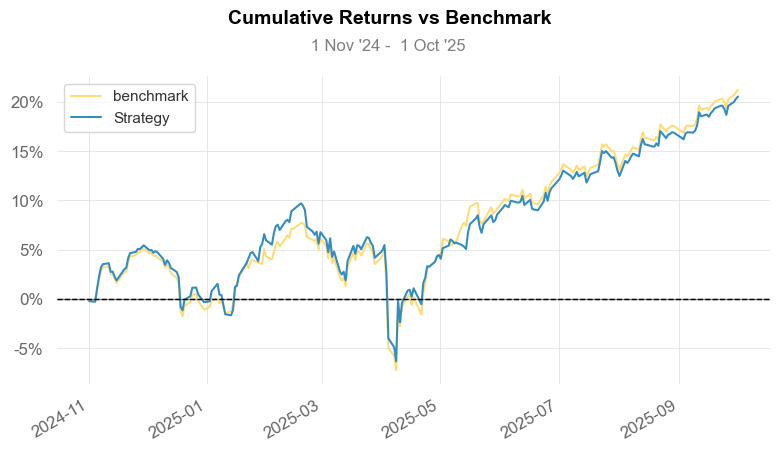

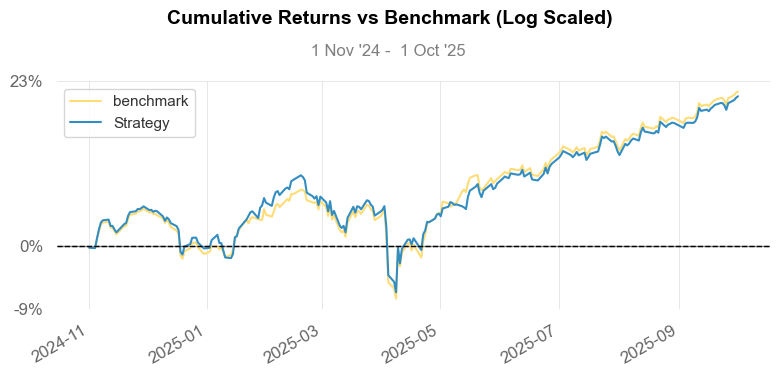

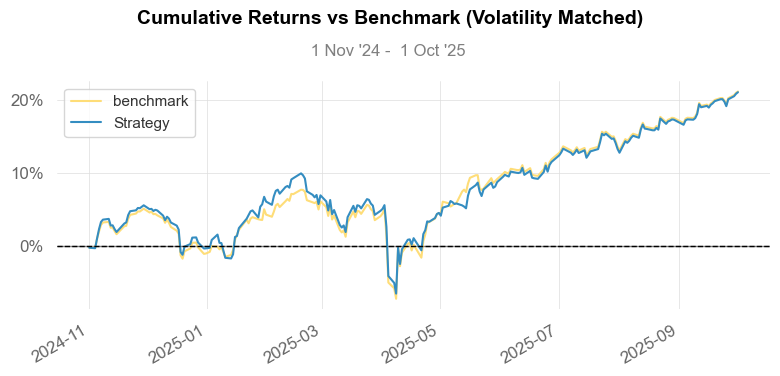

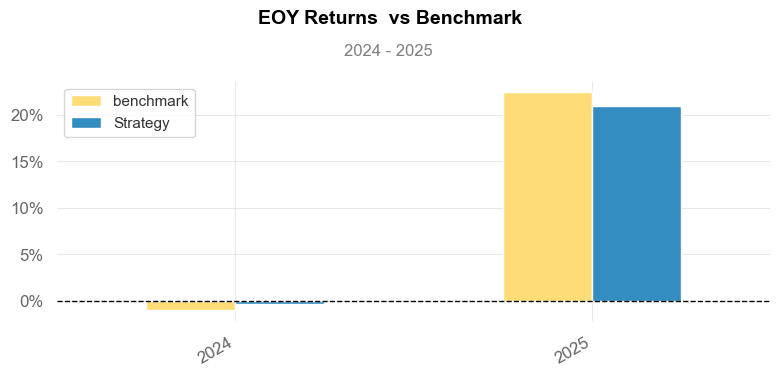

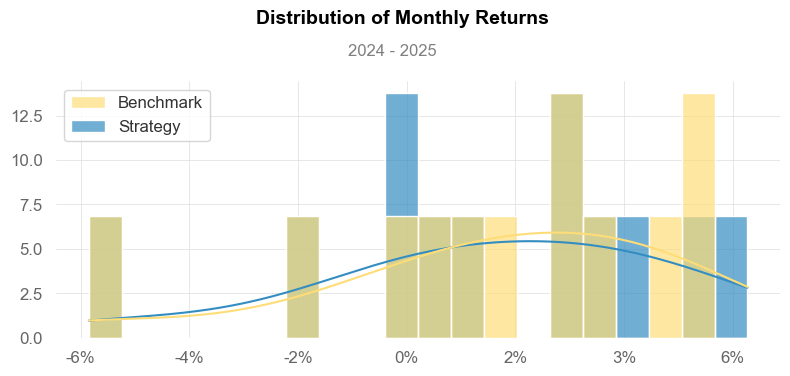

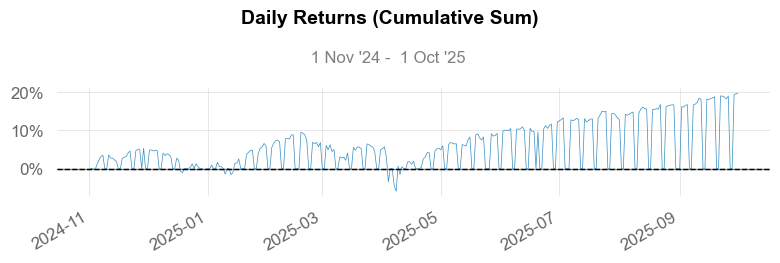

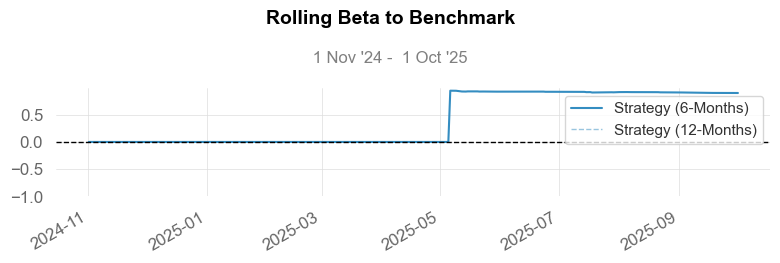

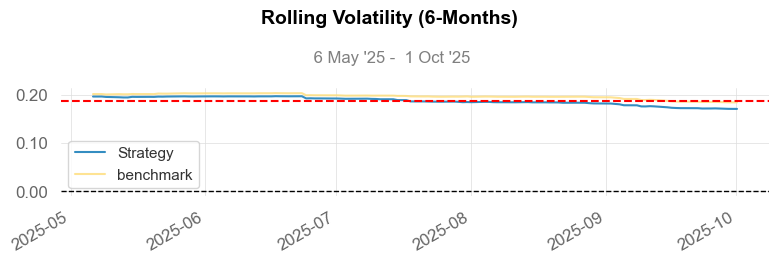

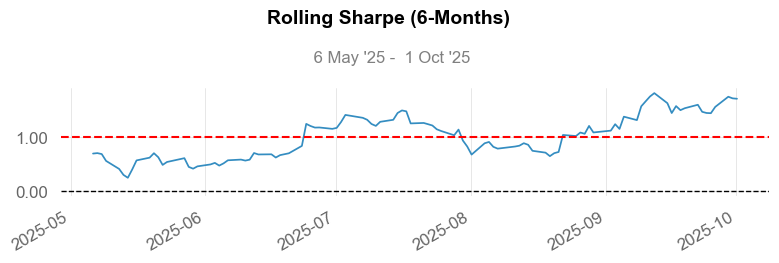

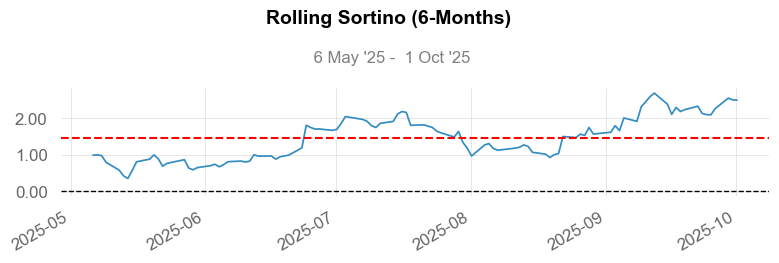

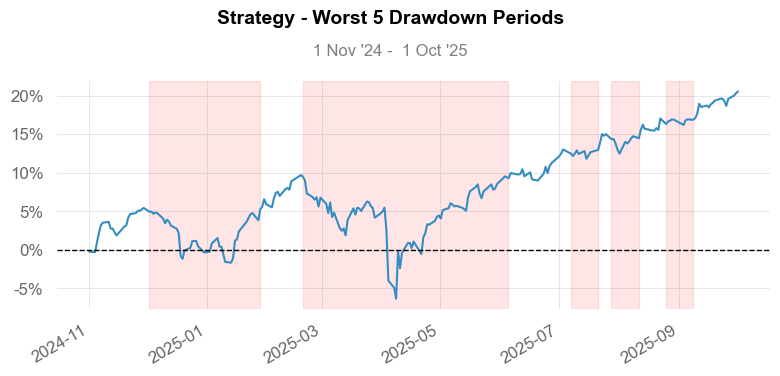

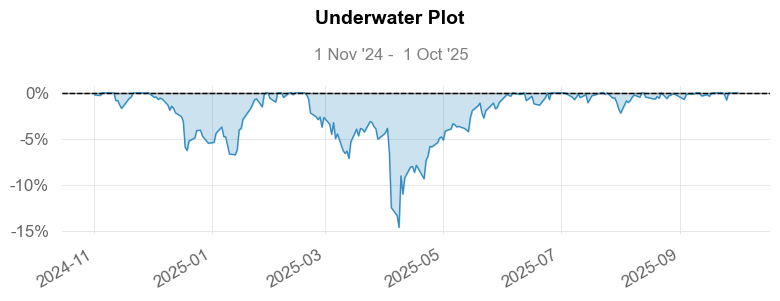

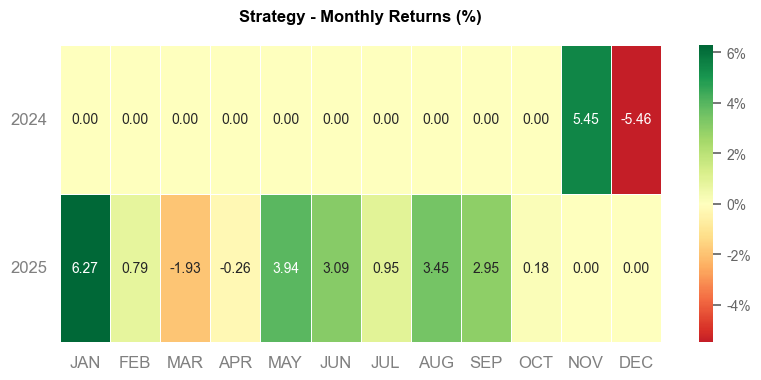

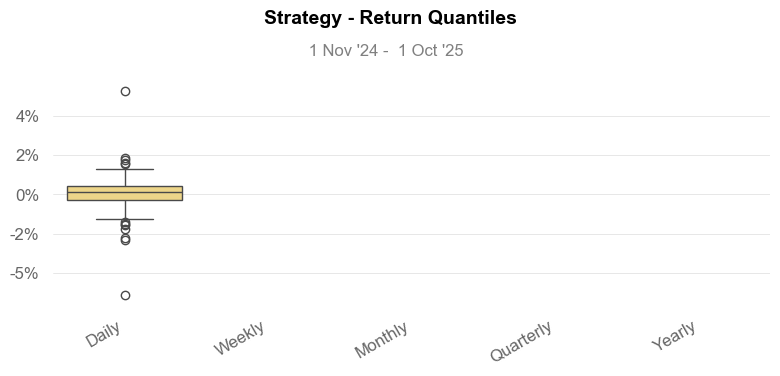

✓ QuantStats complete. Open 'tearsheet_rf_strategy.html' for the full report.


In [3]:
# === QuantStats tear sheet from RF monthly signals (next-month rebalancing) ===
import numpy as np
import pandas as pd

# --- 0) Preconditions ---
# We assume the previous cell defined:
#   df .............. full daily dataframe with columns: ['Date','Sector','Return', ...]
#   monthly_summary . output of aggregate_monthly_returns(df_test, y_test, y_pred)
#                      with columns: ['Sector','YearMonth','Actual_Return','Predicted_Return',
#                                     'Actual_Direction','Predicted_Direction']
assert 'df' in globals(), "Need the full dataframe `df` from the previous cell."
assert 'monthly_summary' in globals(), "Run `aggregate_monthly_returns` to produce `monthly_summary` first."

# --- 1) Build monthly signals and SHIFT to trade NEXT month (avoid look-ahead) ---
sig = monthly_summary.copy()
sig['Month'] = pd.PeriodIndex(sig['YearMonth'], freq='M')
sig['Signal'] = (sig['Predicted_Direction'] == 'up').astype(int)
sig = sig[['Sector', 'Month', 'Signal']].copy()

# trade in t+1 using info from t
sig['TradeMonth'] = sig['Month'] + 1
signals_for_merge = sig[['Sector', 'TradeMonth', 'Signal']].rename(columns={'TradeMonth': 'Month'})

# --- 2) Build DAILY sector equal-weight returns over the full test window inferred from signals ---
test_start = signals_for_merge['Month'].min().to_timestamp(how='start')
test_end   = signals_for_merge['Month'].max().to_timestamp(how='end')

df2 = df.copy()
df2['Date'] = pd.to_datetime(df2['Date'])
daily = df2[(df2['Date'] >= test_start) & (df2['Date'] <= test_end)].dropna(subset=['Return']).copy()

# sector-day equal-weight return
sec_daily = (daily.groupby(['Date','Sector'])['Return']
                  .mean()
                  .reset_index(name='SecRet'))
sec_daily['Month'] = sec_daily['Date'].dt.to_period('M')

# --- 3) Attach monthly (t+1) signals to each sector-day within that trading month ---
sec_daily = sec_daily.merge(signals_for_merge, on=['Sector','Month'], how='left')
sec_daily['Signal'] = sec_daily['Signal'].fillna(0).astype(int)

# --- 4) Strategy & Benchmark daily returns ---
def _avg_selected(g):
    n = g['Signal'].sum()
    if n <= 0:
        return 0.0
    return g.loc[g['Signal'] == 1, 'SecRet'].mean()

strat_ret = sec_daily.groupby('Date').apply(_avg_selected).rename('strategy').sort_index()
bench_ret = (sec_daily.groupby('Date')['SecRet'].mean().rename('benchmark').sort_index())

print(f"QS window: {strat_ret.index.min().date()} → {strat_ret.index.max().date()}")
print(pd.concat([strat_ret.head(3), bench_ret.head(3)], axis=1))

# --- 5) QuantStats tear sheet (inline + HTML) ---
try:
    import quantstats as qs
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "quantstats"])
    import quantstats as qs

# ensure DatetimeIndex
strat_ret.index = pd.DatetimeIndex(strat_ret.index)
bench_ret.index = pd.DatetimeIndex(bench_ret.index)

# Inline summary (and save full HTML report)
qs.reports.html(
    strat_ret,
    benchmark=bench_ret,
    title="RF Directional Strategy (Next-Month, Long-Only)",
    output="tearsheet_rf_strategy.html",
    figfmt="png"
)

qs.reports.full(
    strat_ret,
    benchmark=bench_ret,
    title="RF Directional Strategy (Next-Month, Long-Only)",
    display=True,
    output=None
)

print("✓ QuantStats complete. Open 'tearsheet_rf_strategy.html' for the full report.")